In [20]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [21]:
import urllib.request
 
URL = "https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt"
 
with urllib.request.urlopen(URL) as response:
    text = response.read().decode("utf-8")
 
words = [line.strip() for line in text.splitlines() if line.strip()]

In [22]:
words

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn',
 'abigail',
 'emily',
 'elizabeth',
 'mila',
 'ella',
 'avery',
 'sofia',
 'camila',
 'aria',
 'scarlett',
 'victoria',
 'madison',
 'luna',
 'grace',
 'chloe',
 'penelope',
 'layla',
 'riley',
 'zoey',
 'nora',
 'lily',
 'eleanor',
 'hannah',
 'lillian',
 'addison',
 'aubrey',
 'ellie',
 'stella',
 'natalie',
 'zoe',
 'leah',
 'hazel',
 'violet',
 'aurora',
 'savannah',
 'audrey',
 'brooklyn',
 'bella',
 'claire',
 'skylar',
 'lucy',
 'paisley',
 'everly',
 'anna',
 'caroline',
 'nova',
 'genesis',
 'emilia',
 'kennedy',
 'samantha',
 'maya',
 'willow',
 'kinsley',
 'naomi',
 'aaliyah',
 'elena',
 'sarah',
 'ariana',
 'allison',
 'gabriella',
 'alice',
 'madelyn',
 'cora',
 'ruby',
 'eva',
 'serenity',
 'autumn',
 'adeline',
 'hailey',
 'gianna',
 'valentina',
 'isla',
 'eliana',
 'quinn',
 'nevaeh',
 'ivy',
 'sadie',
 'piper',
 'lydia',
 'alexa',
 'josephine',
 'emery',
 'julia'

In [23]:
NUM_LETTERS = 26
NUM_SPECIAL = 1
NUM_TOKENS = NUM_LETTERS + NUM_SPECIAL

alphabet = list(bytes([list('a'.encode("utf-8"))[0] + i for i in range(NUM_LETTERS)]).decode('utf-8'))

stoi = {
    ".": 0
}
itos = {
    0: "."
}
for i, s in enumerate(alphabet):
    stoi[s] = i + 1
    itos[i + 1] = s

itos

{0: '.',
 1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z'}

In [24]:
import random
CONTEXT_SIZE = 3

def build_dataset(words):
    X, Y = [], []

    for w in words:
        w = w.lower()
        context = [0] * CONTEXT_SIZE
        for s in w + ".":
            i = stoi[s]
            X.append(context)
            Y.append(i)
            context = context[1:] + [i]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)

    return X, Y

random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

# split the dataset into training, validation (dev) and test sets
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [25]:
# if the NN weights were set uniform at random, we would expect the NLL to be 1/27 (each character is equally probable)
# therefore, we want the first loss to be roughly -log(1/27)

-torch.tensor(1/27.0).log()

tensor(3.2958)

In [26]:
EMBEDDING_SIZE = 10
NUM_HIDDED_NEURONS = 200

# if we randomly initialize the parameters, the NN is going to be confidently wrong and therefore the first loss will be really high
# this is undersired, as the several initial iterations will be wasted in getting the neural network less confidently wrong
# to avoid this, we set the bias to 0 and ensure the weights are small so that they do not make the loss unnecessarily high

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((NUM_TOKENS, EMBEDDING_SIZE), generator=g)
W1 = torch.randn((CONTEXT_SIZE * EMBEDDING_SIZE), NUM_HIDDED_NEURONS, generator=g)
b1 = torch.randn(NUM_HIDDED_NEURONS, generator=g)
W2 = torch.randn(NUM_HIDDED_NEURONS, NUM_TOKENS, generator=g) * 0.01
b2 = torch.randn(NUM_TOKENS, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(f"number of parameters: {sum([p.nelement() for p in parameters])}")

for p in parameters:
    p.requires_grad = True

number of parameters: 11897


In [27]:
TRAINING_STEPS = 200_000
BATCH_SIZE = 32

lossi = []
for i in range(TRAINING_STEPS):
    idx = torch.randint(0, Xtr.shape[0], (BATCH_SIZE, ), generator=g)

    # forward
    emb = C[Xtr[idx]] # sample a random subset (of size BATCH_SIZE) of the input
    h = torch.tanh(emb.view(-1, CONTEXT_SIZE * EMBEDDING_SIZE) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[idx])

    # backward
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100_000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # stats
    if i % 10_000 == 0:
        print(f"{i:7d}/{TRAINING_STEPS:7d}: {loss.item():.4f}")
        lossi.append(loss.item())

# the inital loss is roughly the expected log(1/27), ensuring the NN is not unnecessarily biased and wrong

      0/ 200000: 3.3221
  10000/ 200000: 2.1900
  20000/ 200000: 2.4196
  30000/ 200000: 2.6067
  40000/ 200000: 2.0601
  50000/ 200000: 2.4988
  60000/ 200000: 2.3902
  70000/ 200000: 2.1344
  80000/ 200000: 2.3369
  90000/ 200000: 2.1299
 100000/ 200000: 1.8329
 110000/ 200000: 2.2053
 120000/ 200000: 1.8540
 130000/ 200000: 2.4566
 140000/ 200000: 2.1879
 150000/ 200000: 2.1118
 160000/ 200000: 1.8956
 170000/ 200000: 1.8644
 180000/ 200000: 2.0326
 190000/ 200000: 1.8417


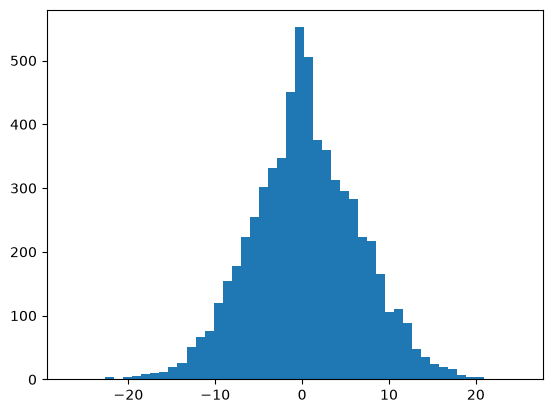

In [28]:
# the distribution of the preactivation is really wide
# and this causes the values far from the norm to be squash on the -1 or 1 side of the activations
hpreact = emb.view(-1, CONTEXT_SIZE * EMBEDDING_SIZE) @ W1 + b1
plt.hist(hpreact.view(-1).tolist(), 50);

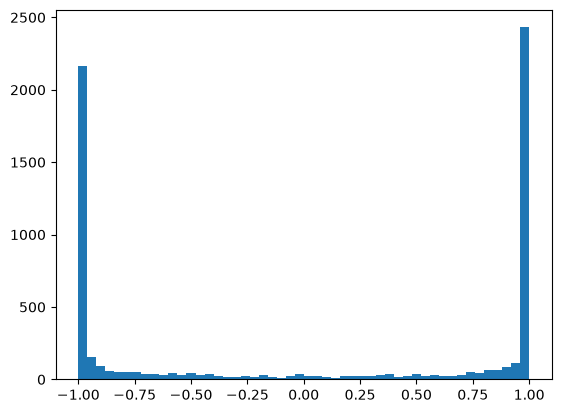

In [29]:
# !!! the values of most of the activations are either -1 or 1 !!!
# this is a big problem because the derivative on tanh when tanh is either -1 or 1 is 0
# therefore, all the gradients of these parameters are not actually being updated during backpropagation
plt.hist(h.view(-1).tolist(), 50);

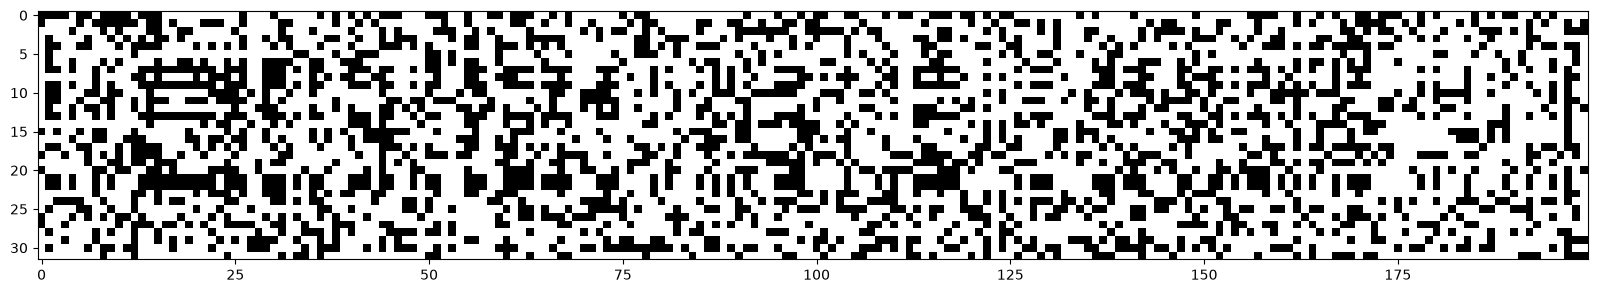

In [30]:
# if a neuron happens to have the activations in either -1 or 1 for all the samples in the minibatch (32 rows)
# the neuron would be a dead neuron, i.e. it cannot learn (would result in a column full of white squares)
# luckily in this case, there is none and so each neuron is in the active part of the tanh for some samples of the minibatch and so it will learn
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

In [44]:
# to prevent the activitation from saturating, we need to ensure that the values of the preactivations are "small"
# to ensure this we also scale the values of W1 and b1 so that the preactivation is closer to 0

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((NUM_TOKENS, EMBEDDING_SIZE), generator=g)
W1 = torch.randn((CONTEXT_SIZE * EMBEDDING_SIZE), NUM_HIDDED_NEURONS, generator=g) * 0.1
b1 = torch.randn(NUM_HIDDED_NEURONS, generator=g) * 0.01
W2 = torch.randn(NUM_HIDDED_NEURONS, NUM_TOKENS, generator=g) * 0.01
b2 = torch.randn(NUM_TOKENS, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(f"number of parameters: {sum([p.nelement() for p in parameters])}")

for p in parameters:
    p.requires_grad = True

number of parameters: 11897


In [45]:
TRAINING_STEPS = 1
BATCH_SIZE = 32

lossi = []
for i in range(TRAINING_STEPS):
    idx = torch.randint(0, Xtr.shape[0], (BATCH_SIZE, ), generator=g)

    # forward
    emb = C[Xtr[idx]] # sample a random subset (of size BATCH_SIZE) of the input
    h = torch.tanh(emb.view(-1, CONTEXT_SIZE * EMBEDDING_SIZE) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[idx])

    # backward
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100_000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # stats
    if i % 10_000 == 0:
        print(f"{i:7d}/{TRAINING_STEPS:7d}: {loss.item():.4f}")
        lossi.append(loss.item())

      0/      1: 3.3069


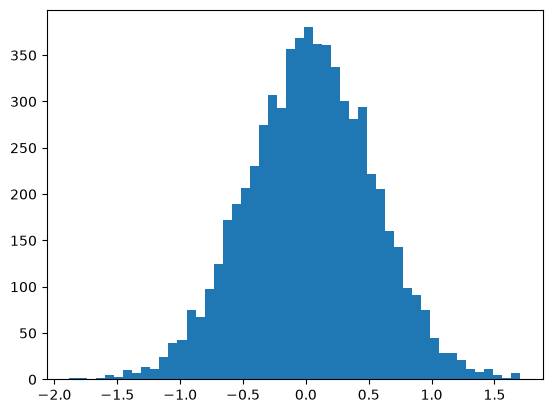

In [46]:
# the distribution of values of the preactivations is now much more narrow
hpreact = emb.view(-1, CONTEXT_SIZE * EMBEDDING_SIZE) @ W1 + b1
plt.hist(hpreact.view(-1).tolist(), 50);

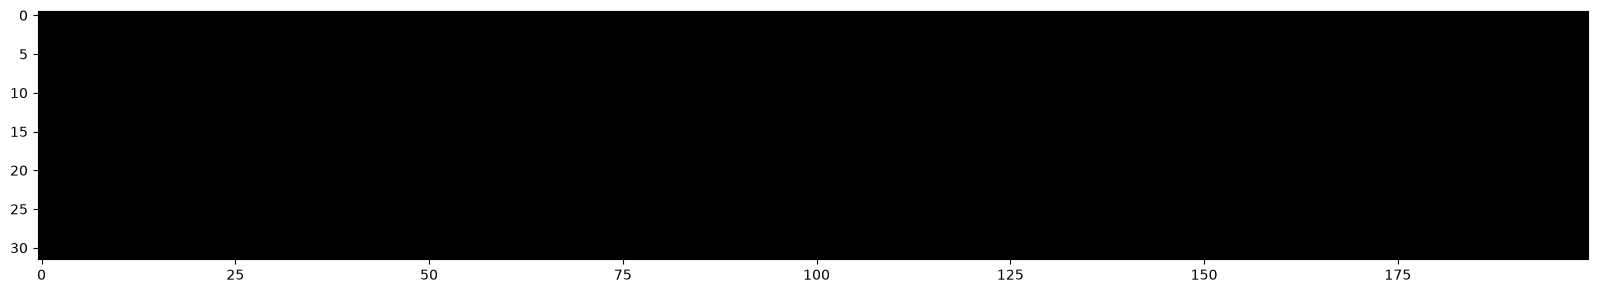

In [47]:
# and finally, all the neurons are being updated for each sample in the batch
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

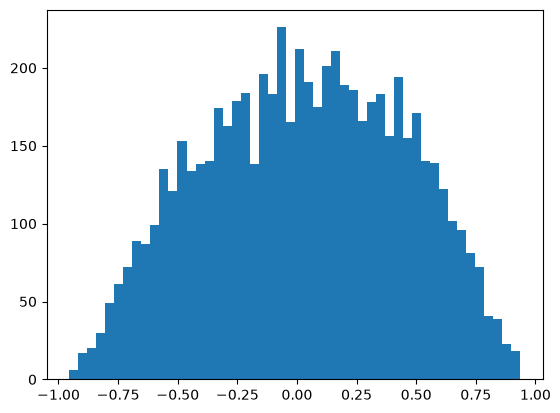

In [48]:
# and so most of the activations are in the active part of the tanh
plt.hist(h.view(-1).tolist(), 50);